## Phase 1

In [14]:
import glob
import pandas as pd
import datetime
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Phase 2 

### Data Aquisition

In [15]:
df = pd.read_csv(r"C:\Users\USER\OneDrive\Documentos\QVI_data.csv")

In [16]:
# VIEW DATASET
df.head()


,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream


In [17]:
print(f"Rows and columns of dataset:  {df.shape}")

df.info()

Rows and columns of dataset:  (264834, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 264834 entries, 0 to 264833
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   LYLTY_CARD_NBR    264834 non-null  int64  
 1   DATE              264834 non-null  object 
 2   STORE_NBR         264834 non-null  int64  
 3   TXN_ID            264834 non-null  int64  
 4   PROD_NBR          264834 non-null  int64  
 5   PROD_NAME         264834 non-null  object 
 6   PROD_QTY          264834 non-null  int64  
 7   TOT_SALES         264834 non-null  float64
 8   PACK_SIZE         264834 non-null  int64  
 9   BRAND             264834 non-null  object 
 10  LIFESTAGE         264834 non-null  object 
 11  PREMIUM_CUSTOMER  264834 non-null  object 
dtypes: float64(1), int64(6), object(5)
memory usage: 24.2+ MB


In [18]:
# convert date column
df['DATE']=pd.to_datetime(df['DATE'])

#Create a year month column
df['YEAR_MONTH'] = df['DATE'].dt.to_period('M')

# Store metrics

In [19]:
store_metrics = df.groupby(['STORE_NBR', 'YEAR_MONTH']).agg({
    'TOT_SALES': 'sum',
    'LYLTY_CARD_NBR': 'nunique',
    'TXN_ID': 'nunique'
}).rename(columns={
    'TOT_SALES': 'total_sales',
    'LYLTY_CARD_NBR': 'total_customers',
    'TXN_ID': 'number_of_transactions'
}).reset_index()

# what's the avg transaction per customer
store_metrics['avg_transaction_per_customer'] = (store_metrics['number_of_transactions'] / store_metrics['total_customers'])

store_metrics.head(5)

,STORE_NBR,YEAR_MONTH,total_sales,total_customers,number_of_transactions,avg_transaction_per_customer
0,1,2018-07,206.9,49,52,1.061224
1,1,2018-08,176.1,42,43,1.023810
2,1,2018-09,278.8,59,62,1.050847
3,1,2018-10,188.1,44,45,1.022727
4,1,2018-11,192.6,46,47,1.021739


# Store periods
## Split the time period

In [20]:
TRIAL_STORES = [77, 86, 88]
PRE_TRIAL_STARTS = '2018-07'
PRE_TRIAL_ENDS = '2019-01'
TRIAL_STARTS = '2019-02'
TRIAL_ENDS = '2019-04'

# Filter data for pre-trial and trial periods
pre_trial = store_metrics[
    (store_metrics['YEAR_MONTH'] >= PRE_TRIAL_STARTS) &
    (store_metrics['YEAR_MONTH'] <= PRE_TRIAL_ENDS)
]

trial = store_metrics[
    (store_metrics['YEAR_MONTH'] >= TRIAL_STARTS) &
    (store_metrics['YEAR_MONTH'] <= TRIAL_ENDS)
]

# Compare the store
## Match each trial store with similar control store

In [21]:
def find_control_store(trial_store, pre_trial):

    trial_data = pre_trial[pre_trial['STORE_NBR'] == trial_store]

    best_store = None
    best_score = -1

    for store in pre_trial['STORE_NBR'].unique():

        if store == trial_store:
            continue

        control_data = pre_trial[pre_trial['STORE_NBR'] == store]

        merged = pd.merge(
            trial_data,
            control_data,
            on='YEAR_MONTH',
            suffixes=('_trial', '_control')
        )

        if len(merged) < 3:
            continue

        corr = merged['total_sales_trial'].corr(
            merged['total_sales_control']
        )

        if corr > best_score:
            best_score = corr
            best_store = store

    return best_store

control_stores = {}

for store in TRIAL_STORES:
    control_stores[store] = find_control_store(store, pre_trial)

print(control_stores)

{77: np.int64(71), 86: np.int64(155), 88: np.int64(159)}


# Compare the store perfomances


In [22]:
def compare_growth(trial_store, control_store):

    # trial period
    trial_store_trial = trial[trial['STORE_NBR'] == trial_store]
    control_store_trial = trial[trial['STORE_NBR'] == control_store]

    # pre-trial period
    trial_store_pre = pre_trial[pre_trial['STORE_NBR'] == trial_store]
    control_store_pre = pre_trial[pre_trial['STORE_NBR'] == control_store]

    # averages
    trial_avg = trial_store_trial['total_sales'].mean()
    control_avg = control_store_trial['total_sales'].mean()

    pre_trial_avg = trial_store_pre['total_sales'].mean()
    pre_control_avg = control_store_pre['total_sales'].mean()

    # growth
    trial_growth = trial_avg - pre_trial_avg
    control_growth = control_avg - pre_control_avg

    # impact
    impact = trial_growth - control_growth

    print(f"\nStore {trial_store} vs Control {control_store}")
    print(f"Trial Growth: {trial_growth:.2f}")
    print(f"Control Growth: {control_growth:.2f}")
    print(f"Impact: {impact:.2f}")

    # interpretation (THIS is what proves your argument)
    if impact > 0:
        print("👉 Positive trial effect")
    else:
        print("👉 No clear positive effect")

for store in TRIAL_STORES:
    compare_growth(store, control_stores[store])


Store 77 vs Control 71
Trial Growth: 16.29
Control Growth: 87.02
Impact: -70.74
👉 No clear positive effect

Store 86 vs Control 155
Trial Growth: 55.14
Control Growth: -54.51
Impact: 109.65
👉 Positive trial effect

Store 88 vs Control 159
Trial Growth: 88.42
Control Growth: 13.64
Impact: 74.78
👉 Positive trial effect


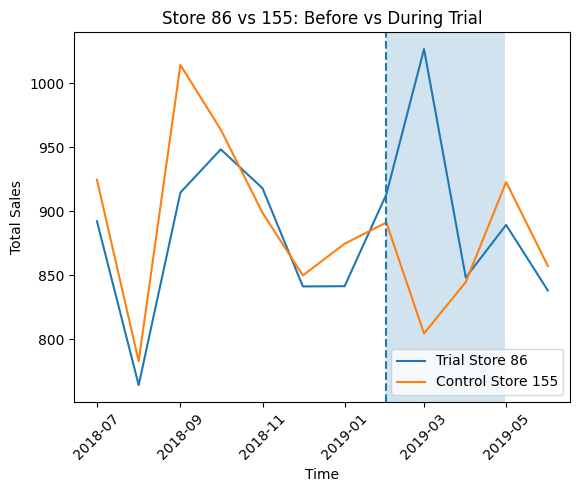

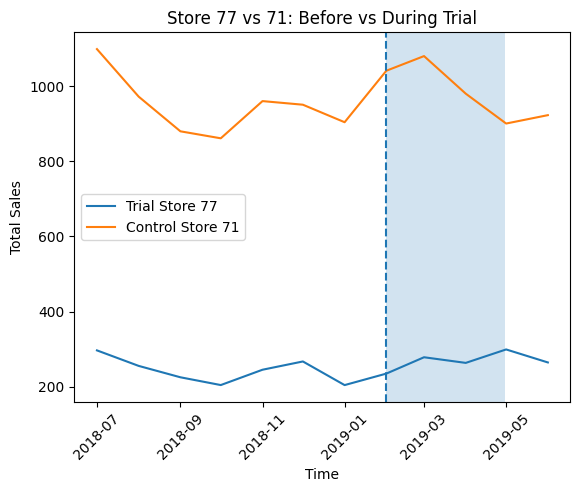

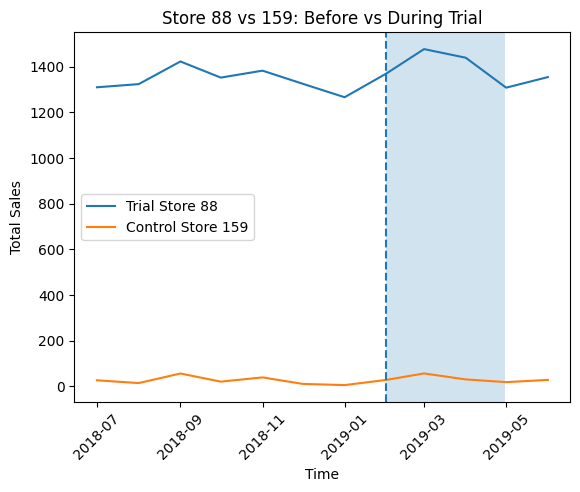

In [23]:


def plot_store(trial_store, control_store):

    # convert to datetime
    store_metrics['YEAR_MONTH'] = pd.to_datetime(store_metrics['YEAR_MONTH'].astype(str))

    trial_store_data = store_metrics[store_metrics['STORE_NBR'] == trial_store]
    control_store_data = store_metrics[store_metrics['STORE_NBR'] == control_store]

    plt.figure()

    plt.plot(trial_store_data['YEAR_MONTH'],
             trial_store_data['total_sales'],
             label=f'Trial Store {trial_store}')

    plt.plot(control_store_data['YEAR_MONTH'],
             control_store_data['total_sales'],
             label=f'Control Store {control_store}')

    # mark trial period
    plt.axvline(pd.to_datetime('2019-02-01'), linestyle='--')
    plt.axvspan(pd.to_datetime('2019-02-01'),
                pd.to_datetime('2019-04-30'),
                alpha=0.2)

    plt.title(f'Store {trial_store} vs {control_store}: Before vs During Trial')
    plt.xlabel('Time')
    plt.ylabel('Total Sales')

    plt.legend()
    plt.xticks(rotation=45)

    plt.show()

plot_store(86, 155)
plot_store(77, 71)
plot_store(88, 159)

SUMMARY: Trial Store Performance vs Control Stores
 Trial Store  Control Store  Trial Growth ($)  Control Growth ($)  Impact  Positive Effect
          77             71             16.29               87.02   -70.74            ❌ No
          86            155             55.14              -54.51   109.65           ✅ Yes
          88            159             88.42               13.64    74.78           ✅ Yes


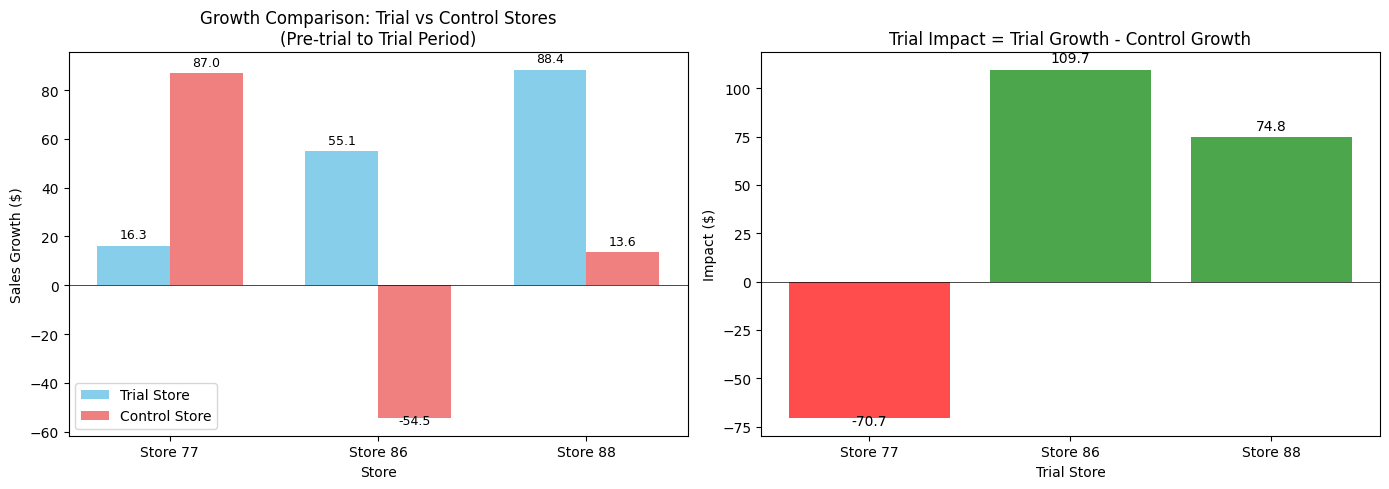

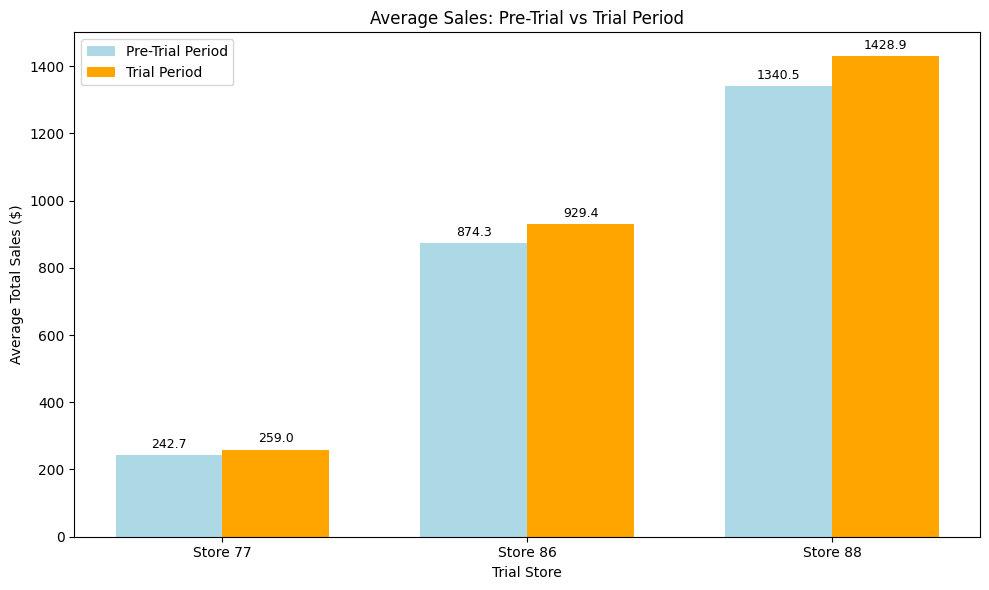


FINAL ASSESSMENT
❌ Store 77: NO POSITIVE EFFECT - Negative impact of $-70.74
✅ Store 86: SUCCESS - Positive impact of $109.65
✅ Store 88: SUCCESS - Positive impact of $74.78

📊 Summary:
- Stores with positive trial effect: 2/3
- Average impact across trial stores: $37.90


In [24]:
# Data from your earlier output
stores_data = {
    77: {'control': 71, 'trial_growth': 16.29, 'control_growth': 87.02, 'impact': -70.74},
    86: {'control': 155, 'trial_growth': 55.14, 'control_growth': -54.51, 'impact': 109.65},
    88: {'control': 159, 'trial_growth': 88.42, 'control_growth': 13.64, 'impact': 74.78}
}

# Create summary DataFrame
import pandas as pd
summary_df = pd.DataFrame([
    {
        'Trial Store': store,
        'Control Store': data['control'],
        'Trial Growth ($)': data['trial_growth'],
        'Control Growth ($)': data['control_growth'],
        'Impact ': data['impact'],
        'Positive Effect': '✅ Yes' if data['impact'] > 0 else '❌ No'
    }
    for store, data in stores_data.items()
])

print("=" * 80)
print("SUMMARY: Trial Store Performance vs Control Stores")
print("=" * 80)
print(summary_df.to_string(index=False))
print("=" * 80)

# Plot 1: Bar chart comparing growth
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: Growth comparison
ax1 = axes[0]
x = np.arange(len(stores_data))
width = 0.35

trial_growths = [data['trial_growth'] for data in stores_data.values()]
control_growths = [data['control_growth'] for data in stores_data.values()]
store_labels = [f"Store {s}" for s in stores_data.keys()]

bars1 = ax1.bar(x - width/2, trial_growths, width, label='Trial Store', color='skyblue')
bars2 = ax1.bar(x + width/2, control_growths, width, label='Control Store', color='lightcoral')

ax1.set_xlabel('Store')
ax1.set_ylabel('Sales Growth ($)')
ax1.set_title('Growth Comparison: Trial vs Control Stores\n(Pre-trial to Trial Period)')
ax1.set_xticks(x)
ax1.set_xticklabels(store_labels)
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax1.legend()

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom' if height >= 0 else 'top',
                    fontsize=9)

# Plot 2: Impact bar chart
ax2 = axes[1]
impacts = [data['impact'] for data in stores_data.values()]
colors = ['green' if imp > 0 else 'red' for imp in impacts]
bars = ax2.bar(store_labels, impacts, color=colors, alpha=0.7)
ax2.set_xlabel('Trial Store')
ax2.set_ylabel('Impact ($)')
ax2.set_title('Trial Impact = Trial Growth - Control Growth')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

# Add value labels
for bar, imp in zip(bars, impacts):
    ax2.annotate(f'{imp:.1f}',
                xy=(bar.get_x() + bar.get_width()/2, imp),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom' if imp >= 0 else 'top',
                fontsize=10)

plt.tight_layout()
plt.show()

# Plot 3: Side-by-side before/after comparison
fig, ax = plt.subplots(figsize=(10, 6))

# Calculate pre-trial and trial averages
pre_trial_avg = {}
trial_avg = {}

for store in stores_data.keys():
    store_pre = pre_trial[pre_trial['STORE_NBR'] == store]
    store_trial = trial[trial['STORE_NBR'] == store]
    pre_trial_avg[store] = store_pre['total_sales'].mean()
    trial_avg[store] = store_trial['total_sales'].mean()

x_pos = np.arange(len(stores_data))
width = 0.35

pre_bars = ax.bar(x_pos - width/2, pre_trial_avg.values(), width, label='Pre-Trial Period', color='lightblue')
trial_bars = ax.bar(x_pos + width/2, trial_avg.values(), width, label='Trial Period', color='orange')

ax.set_xlabel('Trial Store')
ax.set_ylabel('Average Total Sales ($)')
ax.set_title('Average Sales: Pre-Trial vs Trial Period')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Store {s}' for s in stores_data.keys()])
ax.legend()

# Add value labels
for bars in [pre_bars, trial_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                   xy=(bar.get_x() + bar.get_width()/2, height),
                   xytext=(0, 3),
                   textcoords="offset points",
                   ha='center', va='bottom',
                   fontsize=9)

plt.tight_layout()
plt.show()

# Final conclusion
print("\n" + "=" * 80)
print("FINAL ASSESSMENT")
print("=" * 80)
for store, data in stores_data.items():
    if data['impact'] > 0:
        print(f"✅ Store {store}: SUCCESS - Positive impact of ${data['impact']:.2f}")
    else:
        print(f"❌ Store {store}: NO POSITIVE EFFECT - Negative impact of ${data['impact']:.2f}")

print("\n📊 Summary:")
print(f"- Stores with positive trial effect: {sum(1 for d in stores_data.values() if d['impact'] > 0)}/3")
print(f"- Average impact across trial stores: ${np.mean(impacts):.2f}")

# 📊 Trial Store Performance Analysis

## Overview
A trial was conducted across three stores (**77, 86, and 88**) from **February 2019 to April 2019**.  
Each trial store was matched with a control store based on **pre-trial sales correlation** (July 2018 – January 2019).

Performance was evaluated by comparing **sales growth from the pre-trial period to the trial period**.

---

## 🔑 Key Results

### 1. Mixed Outcomes: 2 of 3 Stores Showed Positive Impact

| Trial Store | Control Store | Trial Growth ($) | Control Growth ($) | Impact ($) | Outcome |
|------------|--------------|------------------|---------------------|------------|---------|
| 86         | 155          | +55.14           | -54.51              | +109.65    | ✅ Positive |
| 88         | 159          | +88.42           | +13.64              | +74.78     | ✅ Positive |
| 77         | 71           | +16.29           | +87.02              | -70.74     | ❌ Negative |

**Success Rate:** 67% (2 out of 3 stores)

---

### 2. Store 86: Strongest Success
- Trial store sales increased by **$55.14**
- Control store sales decreased by **$54.51**
- **Net positive impact: +$109.65**

**Interpretation:**  
The trial intervention likely drove sales growth while the control store (and possibly the broader market) declined.

---

### 3. Store 88: Clear Sales Lift
- Trial store sales increased by **$88.42**
- Control store sales increased modestly by **$13.64**
- **Net positive impact: +$74.78**

**Interpretation:**  
The trial store significantly outperformed its expected (natural) growth trajectory.

---

### 4. Store 77: No Positive Effect
- Trial store sales increased by **$16.29**
- Control store sales increased by **$87.02**
- **Net negative impact: -$70.74**

**Interpretation:**  
The trial store underperformed relative to its control, suggesting the intervention was ineffective in this case.

---

## 📈 Visual Evidence

Time-series analysis supports these findings:

- **Store 86 vs 155:** Trial store trends upward while control declines  
- **Store 88 vs 159:** Clear sales lift during trial period vs relatively flat control  
- **Store 77 vs 71:** Control store consistently outperforms trial  

---

## ⚠️ Limitations

- Control store matching relies solely on **sales correlation**  
- Store 71 (control for Store 77) showed unusually strong growth → may not be a fair benchmark  
- **Short trial period (3 months)** limits robustness  
- No **statistical significance testing** performed  

---

## 📌 Recommendations

| Priority | Recommendation |
|----------|---------------|
| High     | Roll out trial strategy to stores similar to **Stores 86 and 88** |
| Medium   | Investigate why **Store 77** underperformed |
| Medium   | Improve control matching (include customer demographics, store size, location) |
| Low      | Extend trial duration in future experiments |

---

## 🧠 Overall Conclusion

The trial was **partially successful**:

- **Store 86:** Strong positive impact  
- **Store 88:** Positive impact  
- **Store 77:** No measurable benefit  

👉 The strategy should be **selectively scaled**, with further validation and investigation.

---

## 📊 Summary Metric

**Average Impact Across All Trial Stores:**  
➡️ **+$37.90**